Alumna: Rojas, Paola

Materia: Aprendizaje Automatico

Clase N°6 - Video explicativo sobre K-Nearest Neighbors (K-NN) y Regresion Logistica

En esta presentación voy a mostrar un problema de aprendizaje supervisado utilizando dos modelos de clasificación: K-NN y Regresión Logística.

Para desarrollar el trabajo utilice un dataset de estudiantes, con información relacionada a su desempeño académico. El objetivo principal fue predecir si un estudiante aprueba o no, a partir de distintas variables incluidas en el conjunto de datos.

A lo largo del proyecto se entrenaron y evaluaron ambos modelos, comparando sus resultados mediante distintas métricas y matrices de confusión, para analizar cuál ofrece un mejor desempeño en la predicción.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Subimos el archivo
from google.colab import files
files.upload()

# Cargamos el dataset
df = pd.read_csv("estudiantes.csv")

# Mostramos las primeras filas
df.head()

Saving estudiantes.csv to estudiantes.csv


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
# Información general: muestra tipos de datos y cantidad de registros.
df.info()

# Estadísticas descriptivas:
df.describe()

# Verificamos valores nulos: permite verificar si existen valores faltantes.
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
# Verificamos valores únicos
print(df['Extracurricular Activities'].unique())
# Limpiamos espacios
df['Extracurricular Activities'] = df['Extracurricular Activities'].str.strip()

# Convertimos valores categóricos a numéricos
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Verificamos valores nulos
print(df.isnull().sum())
# Eliminamos filas con valores nulos
df = df.dropna()

['Yes' 'No']
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [ ]:
# Creamos la variable objetivo:
# 0 = Desaprobo
# 1 = Aprobo

df['Resultado'] = np.where(df['Performance Index'] >= 60, 1, 0)

# Verificamos la cantidad de casos
df['Resultado'].value_counts()

,count
Resultado,
0,5710
1,4290


La variable Performance Index es numérica y continua.Por eso transformamos el índice de rendimiento en una variable binaria:

0 = Desaprobó
1 = Aprobó

Consideramos que:

si el índice es mayor o igual a 60: el estudiante aprueba,

si es menor a 60: desaprueba.

In [ ]:
# Selección de variables predictoras
# Variables predictoras/entrada (Las variables predictoras seran utilizadas para entrenar los modelos.)
X = df.drop(['Performance Index', 'Resultado'], axis=1)

# Variable objetivo/salida
y = df['Resultado']

In [14]:
# División de datos

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)




Dividimos los datos en:

70% entrenamiento
30% prueba

In [15]:
#Normalización de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Normalizamos los datos para que todas las variables tengan escalas similares.

Esto es especialmente importante para KNN porque trabaja utilizando distancias entre puntos.


Métricas K-NN:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1721
           1       0.96      0.95      0.95      1279

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000


Precisión K-NN:
0.9603333333333334


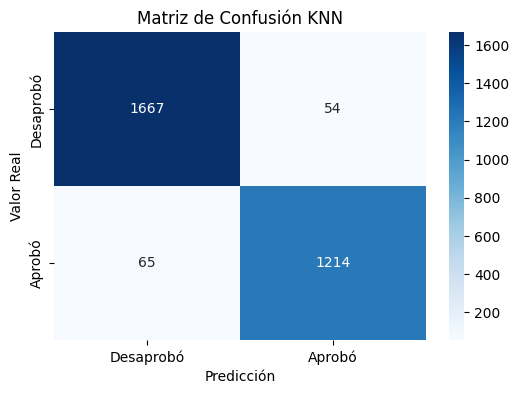

In [16]:
# Modelo KNN

knn = KNeighborsClassifier(n_neighbors=13, weights='distance')

knn.fit(X_train_scaled, y_train)
predicciones_knn = knn.predict(X_test_scaled)

# Métricas
print()
print("Métricas K-NN:")
print(classification_report(y_test, predicciones_knn))

# Precisión
accuracy_knn = accuracy_score(y_test, predicciones_knn)

print()
print("Precisión K-NN:")
print(accuracy_knn)

# Matriz de confusión KNN
cm_knn = confusion_matrix(y_test, predicciones_knn)
plt.figure(figsize=(6,4))

sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", xticklabels=["Desaprobó", "Aprobó"], yticklabels=["Desaprobó", "Aprobó"])


plt.title("Matriz de Confusión KNN")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()





En general el modelo tuvo muy pocos errores y un buen desempeño


Métricas Regresión Logística:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1721
           1       0.98      0.96      0.97      1279

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000


Precisión Regresión Logística:
0.9723333333333334


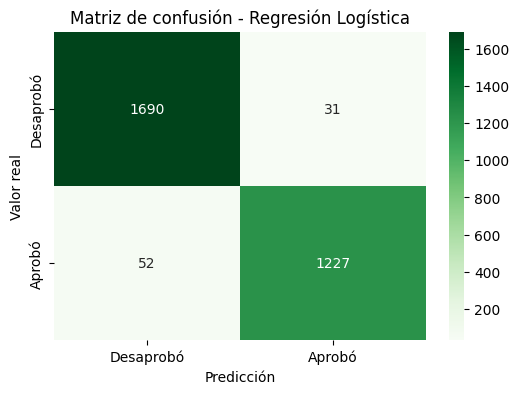

In [17]:
# Modelo Regresión Logística
log_reg = LogisticRegression(max_iter=1000)

# Entrenamiento
log_reg.fit(X_train_scaled, y_train)

# Predicciones
predicciones_log = log_reg.predict(X_test_scaled)

# Métricas
print()
print("Métricas Regresión Logística:")
print(classification_report(y_test, predicciones_log))

# Precisión
accuracy_log = accuracy_score(y_test, predicciones_log)

print()
print("Precisión Regresión Logística:")
print(accuracy_log)

#Matriz de confusion Regresion Logistica

cm_log = confusion_matrix(y_test, predicciones_log)

plt.figure(figsize=(6,4))

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Greens", xticklabels=["Desaprobó", "Aprobó"], yticklabels=["Desaprobó", "Aprobó"])

plt.title("Matriz de confusión - Regresión Logística")
plt.ylabel("Valor real")
plt.xlabel("Predicción")

plt.show()

Los 2 modelos funcionaron muy bien para resolver el problema sin embargo, la regresion logistica obtuvo: una precision un poco mas alta, mejores metricas y menos errores en la matriz de confusion por lo que la regresion logistica fue el modelo que mejor resolvio el problema.